## Model -1 for Home A (Simulated and Real Test Set)
#### Without hidden-dim layers

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
import tensorflow as tf
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt

# Load and preprocess data
data_path = "C:/Users/olufe/projects/Journal/dataset/psa_journal_home_A_unsupervise_train.csv"
data_df = pd.read_csv(data_path)

# Extract features (X) and target labels (y) from the loaded data
X = data_df.drop(columns=["Label"])  # Drop the label column
y = data_df["Label"]  

# Data preprocessing - Normalize the data using MinMaxScaler
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X)
#X_test_scaled = scaler.transform(X_test)

# Print the extracted values of X and y
print("X shape:", X.shape)
print("y shape:", y.shape)


In [ ]:
# Define the autoencoder model with deep layers
input_dim = X_train_scaled.shape[1]
encoding_dim = 64
hidden_dim = 32

input_layer = Input(shape=(input_dim,))
encoder_layer1 = Dense(encoding_dim * 2, activation='relu')(input_layer)
encoder_layer2 = Dense(encoding_dim, activation='relu')(encoder_layer1)
decoder_layer2 = Dense(encoding_dim * 2, activation='relu')(encoder_layer2)
decoder_layer1 = Dense(input_dim, activation='sigmoid')(decoder_layer2)

autoencoder = Model(input_layer, decoder_layer1)
autoencoder.compile(optimizer='adam', loss='mse')

# Define early stopping callback
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# Train the autoencoder on the training set
autoencoder.fit(X_train_scaled, X_train_scaled,
                epochs=100,
                batch_size=32,
                shuffle=True,
                validation_split=0.1,  # Using a portion of training data for validation
                callbacks=[early_stopping])  # Adding the early stopping callback


In [ ]:
# Print the model summary
autoencoder.summary()

# Calculate reconstruction error for test data
train_predictions = autoencoder.predict(X_train_scaled)
reconstruction_error = np.mean(np.square(X_train_scaled - train_predictions), axis=1)

# Print reconstruction errors
print("Reconstruction Errors:")
print(reconstruction_error)

# Calculate threshold using Median Absolute Deviation (MAD)
median = np.median(reconstruction_error)
mad = np.median(np.abs(reconstruction_error - median))
threshold = median + (12 * mad)  # Adjust the multiplier as needed

print("Threshold:", threshold)

# Print and save the trained autoencoder model
model_path = "trained_autoencoder_model.h5"
autoencoder.save(model_path)
print("Model saved at:", model_path)

# Save the threshold
threshold_path = "trained_threshold.npy"
np.save(threshold_path, threshold)
print("Threshold saved at:", threshold_path)

# Visualize the reconstruction error and threshold
plt.figure(figsize=(10, 6))
# plt.figure(figsize=(5, 3))
plt.plot(reconstruction_error, marker='o', linestyle='', color='b', label='Reconstruction Error')
plt.axhline(y=threshold, color='r', linestyle='--', label='Threshold')
plt.xlabel('Sample Index')
plt.ylabel('Reconstruction Error')
plt.title('Reconstruction Error and Home_A Anomaly Threshold Training Data')
plt.legend()
plt.grid()
plt.savefig(r'C:\Users\olufe\projects\Journal\Diagrams\Home_A\mlp-A_Training.png',bbox_inches='tight')
#plt.savefig(r'C:\Users\olufe\projects\Journal\Diagrams\Home_A\mlp-A_rec-err_thr.eps',bbox_inches='tight')
plt.show()


In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, \
    f1_score, roc_curve, roc_auc_score, confusion_matrix
from tensorflow.keras.models import load_model
import matplotlib.pyplot as plt

# Load data paths
data_path_train = "C:/Users/olufe/projects/Journal/dataset/psa_journal_home_A_unsupervise_train.csv"
data_path_test = "C:/Users/olufe/projects/Journal/dataset/psa_journal_home_A_sim_test.csv"

# Load train and test data
train_data = pd.read_csv(data_path_train)
test_data = pd.read_csv(data_path_test)

# Drop the last column to extract features (X) and labels (y) from both datasets
X_train = train_data.drop(columns=['Label']).values
y_train = train_data['Label'].values
X_test = test_data.drop(columns=['Label']).values
y_test = test_data['Label'].values

# Data preprocessing
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Load the trained autoencoder model
autoencoder = load_model("trained_autoencoder_model.h5")

# Calculate reconstruction error for test data
test_predictions = autoencoder.predict(X_test_scaled)
test_reconstruction_error = np.mean(np.square(X_test_scaled - test_predictions), axis=1)

# Load the saved threshold
threshold = np.load("trained_threshold.npy")
print("Threshold saved at:", threshold)

# Classify anomalies based on the threshold
anomalies = test_reconstruction_error > threshold

# Print the indices of anomalous data
print("Anomalous Data Indices:")
anomalous_indices = np.where(anomalies)[0]
print(anomalous_indices)


In [ ]:
# Evaluate performance metrics
accuracy = accuracy_score(y_test, anomalies)
precision = precision_score(y_test, anomalies)
recall = recall_score(y_test, anomalies)
conf_matrix = confusion_matrix(y_test, anomalies)

In [ ]:
import seaborn as sns
# Calculate True Negative Rate (TNR), False Positive Rate (FPR), False Negative Rate (FNR)
tnr = conf_matrix[0, 0] / (conf_matrix[0, 0] + conf_matrix[0, 1])
fpr = conf_matrix[0, 1] / (conf_matrix[0, 0] + conf_matrix[0, 1])
fnr = conf_matrix[1, 0] / (conf_matrix[1, 0] + conf_matrix[1, 1])

f1 = f1_score(y_test, anomalies)
roc_auc = roc_auc_score(y_test, test_reconstruction_error)
fpr_curve, tpr_curve, thresholds_curve = roc_curve(y_test, test_reconstruction_error)

# Print performance metrics
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("TNR:", tnr)
print("FPR:", fpr)
print("FNR:", fnr)
print("F1 Score:", f1)
print("ROC AUC:", roc_auc)

import seaborn as sns

# Calculate the confusion matrix
conf_matrix = confusion_matrix(y_test, anomalies)

# Normalize the confusion matrix
conf_matrix_normalized = conf_matrix.astype('float') / conf_matrix.sum(axis=1)[:, np.newaxis]

# Create a heatmap for the confusion matrix
plt.figure(figsize=(8, 6))
# sns.heatmap(cm_df, annot=True, fmt='0.2f', cmap='Greys', linewidths=0.5, square=True, cbar_kws={'label': 'Home A'}
sns.heatmap(conf_matrix_normalized, annot=True, fmt=".2f", cmap="Greys", linewidths=0.5, square=True, 
            cbar_kws={'label': 'Home A'},
            xticklabels=["Benign", "Attack"], yticklabels=["Benign", "Attack"])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix (Normalized)')
plt.savefig(r'C:\Users\olufe\projects\Journal\Diagrams\Home_A\mlp-A_anomalies_sim_cm.png',bbox_inches='tight')
# plt.savefig(f'Confusion_Matrix_{name}.png')  # Save with the model name
plt.show()

# Plot reconstruction error with anomalous points highlighted
plt.figure(figsize=(10, 6))
plt.plot(test_reconstruction_error, marker='o', linestyle='-', color='b', label='Reconstruction Error')
plt.axhline(y=threshold, color='r', linestyle='--', label='Threshold')

# Highlight anomalous points with unique color and marker
plt.scatter(anomalous_indices, test_reconstruction_error[anomalous_indices],
            color='red', marker='x', s=100, label='Anomalies')

plt.xlabel('Sample Index')
plt.ylabel('Reconstruction Error')
plt.title('Reconstruction Error Plot with Anomalies HomeA_sim_Test')
plt.legend()
plt.grid()
plt.savefig(r'C:\Users\olufe\projects\Journal\Diagrams\Home_A\mlp-A_anomalies_sim.png',bbox_inches='tight')
#plt.savefig(r'C:\Users\olufe\projects\Journal\Diagrams\Home_A\mlp-A_anomalies_sim.eps',bbox_inches='tight')
plt.show()


# Plot ROC curve
plt.figure(figsize=(10, 6))
plt.plot(fpr_curve, tpr_curve, label=f'AUC = {roc_auc:.2f}')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Home_A_Sim_MLP-AE')
plt.legend(loc='lower right')
plt.savefig(r'C:\Users\olufe\projects\Journal\Diagrams\Home_A\mlp-A_ROC_sim.png',bbox_inches='tight')
#plt.savefig(r'C:\Users\olufe\projects\Journal\Diagrams\Home_A\mlp-A_ROC_sim.eps',bbox_inches='tight')
plt.show()


In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, \
    f1_score, roc_curve, roc_auc_score, confusion_matrix
from tensorflow.keras.models import load_model
import matplotlib.pyplot as plt

# Load data paths
data_path_train = "C:/Users/olufe/projects/Journal/dataset/psa_journal_home_A_unsupervise_train.csv"
data_path_test = "C:/Users/olufe/projects/Journal/dataset/psa_journal_home_A_real_test.csv"

# Load train and test data
train_data = pd.read_csv(data_path_train)
test_data = pd.read_csv(data_path_test)

# Drop the last column to extract features (X) and labels (y) from both datasets
X_train = train_data.drop(columns=['Label']).values
y_train = train_data['Label'].values
X_test = test_data.drop(columns=['Label']).values
y_test = test_data['Label'].values

# Data preprocessing
# scaler = MinMaxScaler()
# X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Load the trained autoencoder model
autoencoder = load_model("trained_autoencoder_model.h5")

# Calculate reconstruction error for test data
test_predictions = autoencoder.predict(X_test_scaled)
test_reconstruction_error = np.mean(np.square(X_test_scaled - test_predictions), axis=1)

# Load the saved threshold
threshold = np.load("trained_threshold.npy")
print("Threshold saved at:", threshold)

# Classify anomalies based on the threshold
anomalies = test_reconstruction_error > threshold

# Print the indices of anomalous data
print("Anomalous Data Indices:")
anomalous_indices = np.where(anomalies)[0]
print(anomalous_indices)

# Convert anomalies to binary format
#anomalies_binary = np.where(anomalies, 1, 0)

In [ ]:
test_reconstruction_error

In [ ]:
y_test

In [ ]:
# Evaluate performance metrics
accuracy = accuracy_score(y_test, anomalies)
precision = precision_score(y_test, anomalies)
recall = recall_score(y_test, anomalies)
conf_matrix = confusion_matrix(y_test, anomalies)

In [ ]:
# Calculate True Negative Rate (TNR), False Positive Rate (FPR), False Negative Rate (FNR)
tnr = conf_matrix[0, 0] / (conf_matrix[0, 0] + conf_matrix[0, 1])
fpr = conf_matrix[0, 1] / (conf_matrix[0, 0] + conf_matrix[0, 1])
fnr = conf_matrix[1, 0] / (conf_matrix[1, 0] + conf_matrix[1, 1])

f1 = f1_score(y_test, anomalies)
roc_auc = roc_auc_score(y_test, test_reconstruction_error)
fpr_curve, tpr_curve, thresholds_curve = roc_curve(y_test, test_reconstruction_error)

# Print performance metrics
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("TNR:", tnr)
print("FPR:", fpr)
print("FNR:", fnr)
print("F1 Score:", f1)
print("ROC AUC:", roc_auc)


import seaborn as sns

# Calculate the confusion matrix
conf_matrix = confusion_matrix(y_test, anomalies)

# Normalize the confusion matrix
conf_matrix_normalized = conf_matrix.astype('float') / conf_matrix.sum(axis=1)[:, np.newaxis]

# Create a heatmap for the confusion matrix
plt.figure(figsize=(8, 6))
# sns.heatmap(cm_df, annot=True, fmt='0.2f', cmap='Greys', linewidths=0.5, square=True, cbar_kws={'label': 'Home A'}
sns.heatmap(conf_matrix_normalized, annot=True, fmt=".2f", cmap="Greys", linewidths=0.5, square=True, 
            cbar_kws={'label': 'Home A'},
            xticklabels=["Benign", "Attack"], yticklabels=["Benign", "Attack"])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix (Normalized)')
plt.savefig(r'C:\Users\olufe\projects\Journal\Diagrams\Home_A\mlp-A_anomalies_real_cm.png',bbox_inches='tight')
# plt.savefig(f'Confusion_Matrix_{name}.png')  # Save with the model name
plt.show()

# Plot reconstruction error with anomalous points highlighted
plt.figure(figsize=(10, 6))
plt.plot(test_reconstruction_error, marker='o', linestyle='-', color='b', label='Reconstruction Error')
plt.axhline(y=threshold, color='r', linestyle='--', label='Threshold')

# Highlight anomalous points with unique color and marker
plt.scatter(anomalous_indices, test_reconstruction_error[anomalous_indices],
            color='red', marker='x', s=100, label='Anomalies')

plt.xlabel('Sample Index')
plt.ylabel('Reconstruction Error')
plt.title('Reconstruction Error Plot with Anomalies HomeA_Real_Test')
plt.legend()
plt.grid()
plt.savefig(r'C:\Users\olufe\projects\Journal\Diagrams\Home_A\mlp-A_anomalies_real.png',bbox_inches='tight')
#plt.savefig(r'C:\Users\olufe\projects\Journal\Diagrams\Home_A\mlp-A_anomalies_real.eps',bbox_inches='tight')
plt.show()

# Plot ROC curve
plt.figure(figsize=(10, 6))
plt.plot(fpr_curve, tpr_curve, label=f'AUC = {roc_auc:.2f}')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Home_A_Real_MLP-AE')
plt.legend(loc='lower right')
plt.savefig(r'C:\Users\olufe\projects\Journal\Diagrams\Home_A\mlp-A_ROC_real.png',bbox_inches='tight')
#plt.savefig(r'C:\Users\olufe\projects\Journal\Diagrams\Home_B\mlp-A_ROC_real.eps',bbox_inches='tight')
plt.show()


### Model - 2 for Home A (Simulated and Real Test Set)
#### Implementing hidden-dim layers

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
import tensorflow as tf
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt

# Load and preprocess data
data_path = "C:/Users/olufe/projects/Journal/dataset/psa_journal_home_A_unsupervise_train.csv"
data_df = pd.read_csv(data_path)

# Extract features (X) and target labels (y) from the loaded data
X = data_df.drop(columns=["Label"])  # Drop the label column
y = data_df["Label"]

# Data preprocessing - Normalize the data using MinMaxScaler
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X)
#X_test_scaled = scaler.transform(X_test)

# Print the extracted values of X and y
print("X shape:", X.shape)
print("y shape:", y.shape)
print("X_train_scaled shape:", X_train.shape)
#print("y_train shape:", y_train.shape)


In [ ]:
# Define the autoencoder model with deep layers
input_dim = X_train_scaled.shape[1]
encoding_dim = 64
hidden_dim = 32  # This is the variable you want to use

input_layer = Input(shape=(input_dim,))
encoder_hidden_layer = Dense(hidden_dim, activation='relu')(input_layer)  # Hidden layer
encoder_layer1 = Dense(encoding_dim * 2, activation='relu')(encoder_hidden_layer)
encoder_layer2 = Dense(encoding_dim, activation='relu')(encoder_layer1)
decoder_layer2 = Dense(encoding_dim * 2, activation='relu')(encoder_layer2)
decoder_layer1 = Dense(input_dim, activation='sigmoid')(decoder_layer2)

autoencoder = Model(input_layer, decoder_layer1)
autoencoder.compile(optimizer='adam', loss='mse')

# Define early stopping callback
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# Train the autoencoder on the training set
autoencoder.fit(X_train_scaled, X_train_scaled,
                epochs=100,
                batch_size=32,
                shuffle=True,
                validation_split=0.1,  # Using a portion of training data for validation
                callbacks=[early_stopping])  # Adding the early stopping callback


In [ ]:
# Print the model summary
autoencoder.summary()

# Calculate reconstruction error for test data
train_predictions = autoencoder.predict(X_train_scaled)
reconstruction_error = np.mean(np.square(X_train_scaled - train_predictions), axis=1)

# Print reconstruction errors
print("Reconstruction Errors:")
print(reconstruction_error)

# Calculate threshold using Median Absolute Deviation (MAD)
median = np.median(reconstruction_error)
mad = np.median(np.abs(reconstruction_error - median))
threshold = median + (9 * mad)  # Adjust the multiplier as needed

print("Threshold:", threshold)

# Print and save the trained autoencoder model
model_path = "trained_autoencoder_model.h5"
autoencoder.save(model_path)
print("Model saved at:", model_path)

# Save the threshold
threshold_path = "trained_threshold.npy"
np.save(threshold_path, threshold)
print("Threshold saved at:", threshold_path)

# Visualize the reconstruction error and threshold
plt.figure(figsize=(10, 6))
plt.plot(reconstruction_error, marker='o', linestyle='', label='Reconstruction Error')
plt.axhline(y=threshold, color='r', linestyle='--', label='Threshold')
plt.xlabel('Sample Index')
plt.ylabel('Reconstruction Error')
plt.title('Reconstruction Error and Anomaly Threshold Training Data ')
plt.legend()
plt.grid()
plt.show()


In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, \
    f1_score, roc_curve, roc_auc_score, confusion_matrix
from tensorflow.keras.models import load_model
import matplotlib.pyplot as plt

# Load data paths
data_path_train = "C:/Users/olufe/projects/Journal/dataset/psa_journal_home_A_unsupervise_train.csv"
data_path_test = "C:/Users/olufe/projects/Journal/dataset/psa_journal_home_A_sim_test.csv"

# Load train and test data
train_data = pd.read_csv(data_path_train)
test_data = pd.read_csv(data_path_test)

# Drop the last column to extract features (X) and labels (y) from both datasets
X_train = train_data.drop(columns=['Label']).values
y_train = train_data['Label'].values
X_test = test_data.drop(columns=['Label']).values
y_test = test_data['Label'].values

# Data preprocessing
# scaler = MinMaxScaler()
# X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Load the trained autoencoder model
autoencoder = load_model("trained_autoencoder_model.h5")

# Calculate reconstruction error for test data
test_predictions = autoencoder.predict(X_test_scaled)
test_reconstruction_error = np.mean(np.square(X_test_scaled - test_predictions), axis=1)

# Load the saved threshold
threshold = np.load("trained_threshold.npy")
print("Threshold saved at:", threshold)

# Classify anomalies based on the threshold
anomalies = test_reconstruction_error > threshold

# Print the indices of anomalous data
print("Anomalous Data Indices:")
anomalous_indices = np.where(anomalies)[0]
print(anomalous_indices)


In [ ]:
# Evaluate performance metrics
accuracy = accuracy_score(y_test, anomalies)
precision = precision_score(y_test, anomalies)
recall = recall_score(y_test, anomalies)
conf_matrix = confusion_matrix(y_test, anomalies)

In [ ]:
# Calculate True Negative Rate (TNR), False Positive Rate (FPR), False Negative Rate (FNR)
tnr = conf_matrix[0, 0] / (conf_matrix[0, 0] + conf_matrix[0, 1])
fpr = conf_matrix[0, 1] / (conf_matrix[0, 0] + conf_matrix[0, 1])
fnr = conf_matrix[1, 0] / (conf_matrix[1, 0] + conf_matrix[1, 1])

f1 = f1_score(y_test, anomalies)
roc_auc = roc_auc_score(y_test, test_reconstruction_error)
fpr_curve, tpr_curve, thresholds_curve = roc_curve(y_test, test_reconstruction_error)

# Print performance metrics
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("TNR:", tnr)
print("FPR:", fpr)
print("FNR:", fnr)
print("F1 Score:", f1)
print("ROC AUC:", roc_auc)

import seaborn as sns

# Calculate the confusion matrix
conf_matrix = confusion_matrix(y_test, anomalies)

# Normalize the confusion matrix
conf_matrix_normalized = conf_matrix.astype('float') / conf_matrix.sum(axis=1)[:, np.newaxis]

# Create a heatmap for the confusion matrix
plt.figure(figsize=(8, 6))
# sns.heatmap(cm_df, annot=True, fmt='0.2f', cmap='Greys', linewidths=0.5, square=True, cbar_kws={'label': 'Home A'}
sns.heatmap(conf_matrix_normalized, annot=True, fmt=".2f", cmap="Greys", linewidths=0.5, square=True, 
            cbar_kws={'label': 'Home A_sim'},
            xticklabels=["Benign", "Attack"], yticklabels=["Benign", "Attack"])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix MLP-AE')
plt.savefig(r'C:\Users\olufe\projects\Journal\Diagrams\Home_A\mlp-A_anomalies_sim_dlaye_cm.png',bbox_inches='tight')
# plt.savefig(f'Confusion_Matrix_{name}.png')  # Save with the model name
plt.show()


# Plot reconstruction error with anomalous points highlighted
plt.figure(figsize=(10, 6))
plt.plot(test_reconstruction_error, marker='o', linestyle='-', color='b', label='Reconstruction Error')
plt.axhline(y=threshold, color='r', linestyle='--', label='Threshold')

# Highlight anomalous points with unique color and marker
plt.scatter(anomalous_indices, test_reconstruction_error[anomalous_indices],
            color='red', marker='x', s=100, label='Anomalies')

plt.xlabel('Sample Index')
plt.ylabel('Reconstruction Error')
plt.title('Reconstruction Error Plot with Anomalies HomeA_sim_Test')
plt.legend()
plt.grid()

plt.show()


# Plot ROC curve
plt.figure(figsize=(10, 6))
plt.plot(fpr_curve, tpr_curve, label=f'AUC = {roc_auc:.2f}')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.show()


In [ ]:
import pandas as pd
import numpy as np
import os
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_curve, roc_auc_score, confusion_matrix
from tensorflow.keras.models import load_model
import matplotlib.pyplot as plt
import seaborn as sns

def load_and_preprocess_data(train_path, test_path):
    # Load train and test data
    train_data = pd.read_csv(train_path)
    test_data = pd.read_csv(test_path)

    # Drop the last column to extract features (X) and labels (y) from both datasets
    X_train = train_data.drop(columns=['Label']).values
    y_train = train_data['Label'].values
    X_test = test_data.drop(columns=['Label']).values
    y_test = test_data['Label'].values

    return X_train, y_train, X_test, y_test

def scale_data(X_train, X_test):
    scaler = MinMaxScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    return X_train_scaled, X_test_scaled

def main():
    # Load data paths
    data_path_train = "C:/Users/olufe/projects/Journal/dataset/psa_journal_home_A_unsupervise_train.csv"
    data_path_test = "C:/Users/olufe/projects/Journal/dataset/psa_journal_home_A_sim_test.csv"

    if not os.path.exists(data_path_train) or not os.path.exists(data_path_test):
        print("Data files not found.")
        return

    X_train, y_train, X_test, y_test = load_and_preprocess_data(data_path_train, data_path_test)
    X_train_scaled, X_test_scaled = scale_data(X_train, X_test)

    # Load the trained autoencoder model
    model_path = "trained_autoencoder_model.h5"
    if not os.path.exists(model_path):
        print("Model file not found.")
        return

    autoencoder = load_model(model_path)
    
    # Calculate reconstruction error for test data
    test_predictions = autoencoder.predict(X_test_scaled)
    test_reconstruction_error = np.mean(np.square(X_test_scaled - test_predictions), axis=1)

    # Load the saved threshold
    threshold = np.load("trained_threshold.npy")
    print("Threshold saved at:", threshold)

    # Classify anomalies based on the threshold
    anomalies = test_reconstruction_error > threshold

    # Print the indices of anomalous data
    print("Anomalous Data Indices:")
    anomalous_indices = np.where(anomalies)[0]
    print(anomalous_indices)

    # Evaluate performance metrics
    accuracy = accuracy_score(y_test, anomalies)
    precision = precision_score(y_test, anomalies)
    recall = recall_score(y_test, anomalies)
    conf_matrix = confusion_matrix(y_test, anomalies)
    
    # Calculate True Negative Rate (TNR), False Positive Rate (FPR), False Negative Rate (FNR)
    tnr = conf_matrix[0, 0] / (conf_matrix[0, 0] + conf_matrix[0, 1])
    fpr = conf_matrix[0, 1] / (conf_matrix[0, 0] + conf_matrix[0, 1])
    fnr = conf_matrix[1, 0] / (conf_matrix[1, 0] + conf_matrix[1, 1])

    f1 = f1_score(y_test, anomalies)
    roc_auc = roc_auc_score(y_test, test_reconstruction_error)
    fpr_curve, tpr_curve, thresholds_curve = roc_curve(y_test, test_reconstruction_error)

    # Print performance metrics
    print("Accuracy:", accuracy)
    print("Precision:", precision)
    print("Recall:", recall)
    print("TNR:", tnr)
    print("FPR:", fpr)
    print("FNR:", fnr)
    print("F1 Score:", f1)
    print("ROC AUC:", roc_auc)

# import seaborn as sns

    # Calculate the confusion matrix
    conf_matrix = confusion_matrix(y_test, anomalies)

    # Normalize the confusion matrix
    conf_matrix_normalized = conf_matrix.astype('float') / conf_matrix.sum(axis=1)[:, np.newaxis]

    # Create a heatmap for the confusion matrix
    plt.figure(figsize=(4, 3))
    # sns.heatmap(cm_df, annot=True, fmt='0.2f', cmap='Greys', linewidths=0.5, square=True, cbar_kws={'label': 'Home A'}
    sns.heatmap(conf_matrix_normalized, annot=True, fmt=".2f", cmap="Greys", linewidths=0.5, square=True, 
                cbar_kws={'label': 'Home A_sim'},
                xticklabels=["Benign", "Attack"], yticklabels=["Benign", "Attack"])
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title('Confusion Matrix MLP-AE Home A_sim', fontsize=10, fontweight='bold')
    plt.savefig(r'C:\Users\olufe\projects\Journal\Diagrams\Home_A\mlp-A_anomalies_sim_dlaye_cm.png',bbox_inches='tight')
    # plt.savefig(f'Confusion_Matrix_{name}.png')  # Save with the model name
    plt.show()


    # Plot reconstruction error with anomalous points highlighted
    plt.figure(figsize=(5, 3))
    plt.plot(test_reconstruction_error, marker='o', linestyle='-', color='b', label='Reconstruction Error')
    plt.axhline(y=threshold, color='r', linestyle='--', label='Threshold')

    # Highlight anomalous points with unique color and marker
    plt.scatter(anomalous_indices, test_reconstruction_error[anomalous_indices],
                color='red', marker='x', s=100, label='Anomalies')

    plt.xlabel('Sample Index')
    plt.ylabel('Reconstruction Error')
    plt.title('Reconstruction Error Plot with Anomalies Home A_sim', fontsize=8, fontweight='bold')
    plt.legend()
    plt.grid()
    plt.savefig(r'C:\Users\olufe\projects\Journal\Diagrams\Home_A_up\LUM_MLP-AE.png', bbox_inches='tight')
    plt.show()


    # Plot ROC curve
    plt.figure(figsize=(5, 3))
    plt.plot(fpr_curve, tpr_curve, label=f'AUC = {roc_auc:.2f}')
    plt.plot([0, 1], [0, 1], 'k--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve')
    plt.legend(loc='lower right')
    plt.show()
    
    # Rest of the code...

if __name__ == "__main__":
    main()


In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, \
    f1_score, roc_curve, roc_auc_score, confusion_matrix
from tensorflow.keras.models import load_model
import matplotlib.pyplot as plt

# Load data paths
data_path_train = "C:/Users/olufe/projects/Journal/dataset/psa_journal_home_A_unsupervise_train.csv"
data_path_test = "C:/Users/olufe/projects/Journal/dataset/psa_journal_home_A_real_test.csv"

# Load train and test data
train_data = pd.read_csv(data_path_train)
test_data = pd.read_csv(data_path_test)

# Drop the last column to extract features (X) and labels (y) from both datasets
X_train = train_data.drop(columns=['Label']).values
y_train = train_data['Label'].values
X_test = test_data.drop(columns=['Label']).values
y_test = test_data['Label'].values

# Data preprocessing
# scaler = MinMaxScaler()
# X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Load the trained autoencoder model
autoencoder = load_model("trained_autoencoder_model.h5")

# Calculate reconstruction error for test data
test_predictions = autoencoder.predict(X_test_scaled)
test_reconstruction_error = np.mean(np.square(X_test_scaled - test_predictions), axis=1)

# Load the saved threshold
threshold = np.load("trained_threshold.npy")
print("Threshold saved at:", threshold)

# Classify anomalies based on the threshold
anomalies = test_reconstruction_error > threshold

# Print the indices of anomalous data
print("Anomalous Data Indices:")
anomalous_indices = np.where(anomalies)[0]
print(anomalous_indices)


In [ ]:
test_reconstruction_error

In [ ]:
y_test

In [ ]:
# Evaluate performance metrics
accuracy = accuracy_score(y_test, anomalies)
precision = precision_score(y_test, anomalies)
recall = recall_score(y_test, anomalies)
conf_matrix = confusion_matrix(y_test, anomalies)

In [ ]:
# Calculate True Negative Rate (TNR), False Positive Rate (FPR), False Negative Rate (FNR)
tnr = conf_matrix[0, 0] / (conf_matrix[0, 0] + conf_matrix[0, 1])
fpr = conf_matrix[0, 1] / (conf_matrix[0, 0] + conf_matrix[0, 1])
fnr = conf_matrix[1, 0] / (conf_matrix[1, 0] + conf_matrix[1, 1])

f1 = f1_score(y_test, anomalies)
roc_auc = roc_auc_score(y_test, test_reconstruction_error)
fpr_curve, tpr_curve, thresholds_curve = roc_curve(y_test, test_reconstruction_error)

# Print performance metrics
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("TNR:", tnr)
print("FPR:", fpr)
print("FNR:", fnr)
print("F1 Score:", f1)
print("ROC AUC:", roc_auc)

import seaborn as sns

# Calculate the confusion matrix
conf_matrix = confusion_matrix(y_test, anomalies)

# Normalize the confusion matrix
conf_matrix_normalized = conf_matrix.astype('float') / conf_matrix.sum(axis=1)[:, np.newaxis]

# Create a DataFrame with column and index labels
# cm_df = pd.DataFrame(conf_matrix, columns=['Benign', 'Attack'], index=['Benign', 'Attack'])

# Create a heatmap for the confusion matrix
plt.figure(figsize=(8, 6))
# sns.heatmap(cm_df, annot=True, fmt='0.2f', cmap='Greys', linewidths=0.5, square=True, cbar_kws={'label': 'Home A'}
sns.heatmap(conf_matrix_normalized, annot=True, fmt=".2f", cmap="Greys", linewidths=0.5, square=True, 
            cbar_kws={'label': 'Home A_real'},
            xticklabels=["Benign", "Attack"], yticklabels=["Benign", "Attack"])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix MLP-AE')
plt.savefig(r'C:\Users\olufe\projects\Journal\Diagrams\Home_A\mlp-A_anomalies_real_dlayer_cm.png',bbox_inches='tight')
# plt.savefig(f'Confusion_Matrix_{name}.png')  # Save with the model name
plt.show()

# Plot reconstruction error with anomalous points highlighted
plt.figure(figsize=(10, 6))
plt.plot(test_reconstruction_error, marker='o', linestyle='-', color='b', label='Reconstruction Error')
plt.axhline(y=threshold, color='r', linestyle='--', label='Threshold')

# Highlight anomalous points with unique color and marker
plt.scatter(anomalous_indices, test_reconstruction_error[anomalous_indices],
            color='red', marker='x', s=100, label='Anomalies')

plt.xlabel('Sample Index')
plt.ylabel('Reconstruction Error')
plt.title('Reconstruction Error Plot with Anomalies HomeA_Real_Test')
plt.legend()
plt.grid()

plt.show()

# Plot ROC curve
plt.figure(figsize=(10, 6))
plt.plot(fpr_curve, tpr_curve, label=f'AUC = {roc_auc:.2f}')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.show()


In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, 
    f1_score, roc_curve, roc_auc_score, confusion_matrix
from tensorflow.keras.models import load_model
import matplotlib.pyplot as plt

# Load data paths
data_path_train_sim = "C:/Users/olufe/projects/Journal/dataset/psa_journal_home_A_unsupervise_train.csv"
data_path_test_sim = "C:/Users/olufe/projects/Journal/dataset/psa_journal_home_A_sim_test.csv"

data_path_train_real = "C:/Users/olufe/projects/Journal/dataset/psa_journal_home_A_unsupervise_train.csv"
data_path_test_real = "C:/Users/olufe/projects/Journal/dataset/psa_journal_home_A_real_test.csv"

# Load train and test data for simulated and real datasets
train_data_sim = pd.read_csv(data_path_train_sim)
test_data_sim = pd.read_csv(data_path_test_sim)

train_data_real = pd.read_csv(data_path_train_real)
test_data_real = pd.read_csv(data_path_test_real)

# Drop the last column to extract features (X) and labels (y) from both datasets
X_train_sim = train_data_sim.drop(columns=['Label']).values
y_train_sim = train_data_sim['Label'].values
X_test_sim = test_data_sim.drop(columns=['Label']).values
y_test_sim = test_data_sim['Label'].values

#print(y_test_sim)

X_train_real = train_data_real.drop(columns=['Label']).values
y_train_real = train_data_real['Label'].values
X_test_real = test_data_real.drop(columns=['Label']).values
y_test_real = test_data_real['Label'].values

# Data preprocessing
scaler = MinMaxScaler()
X_train_scaled_sim = scaler.fit_transform(X_train_sim)
X_test_scaled_sim = scaler.transform(X_test_sim)

X_train_scaled_real = scaler.fit_transform(X_train_real)
X_test_scaled_real = scaler.transform(X_test_real)

# Load the trained autoencoder model
autoencoder = load_model("trained_autoencoder_model.h5")

# Calculate reconstruction error for test data
test_predictions_sim = autoencoder.predict(X_test_scaled_sim)
test_reconstruction_error_sim = np.mean(np.square(X_test_scaled_sim - test_predictions_sim), axis=1)

test_predictions_real = autoencoder.predict(X_test_scaled_real)
test_reconstruction_error_real = np.mean(np.square(X_test_scaled_real - test_predictions_real), axis=1)

# Load the saved threshold
threshold_sim = np.load("trained_threshold.npy")
threshold_real = np.load("trained_threshold.npy")
print("Threshold saved at (simulated data):", threshold_sim)
print("Threshold saved at (real data):", threshold_real)

# Classify anomalies based on the threshold
anomalies_sim = test_reconstruction_error_sim > threshold_sim
anomalies_real = test_reconstruction_error_real > threshold_real


In [ ]:
# Compute ROC curve and AUC for both datasets
fpr_curve_sim, tpr_curve_sim, _ = roc_curve(y_test_sim, test_reconstruction_error_sim)
roc_auc_sim = roc_auc_score(y_test_sim, test_reconstruction_error_sim)

fpr_curve_real, tpr_curve_real, _ = roc_curve(y_test_real, test_reconstruction_error_real)
roc_auc_real = roc_auc_score(y_test_real, test_reconstruction_error_real)

# Plot ROC curves for both datasets on the same plot
plt.figure(figsize=(5, 3))
plt.plot(fpr_curve_sim, tpr_curve_sim, label=f'Simulated Data AUC = {roc_auc_sim:.2f}', color='b')
plt.plot(fpr_curve_real, tpr_curve_real, label=f'Real Data AUC = {roc_auc_real:.2f}', color='r')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate', fontsize=10, fontweight='bold')
plt.ylabel('True Positive Rate', fontsize=10, fontweight='bold')
plt.title('ROC Curve for Simulated and Real Data For MLP-AE', fontsize=10)
plt.legend(loc='lower right', fontsize=10)
plt.savefig(r'C:\Users\olufe\projects\Journal\Diagrams\Home_A\MLP-AE_roc_sim_real.png', bbox_inches='tight')
plt.show()


548/548 [==============================] - 1s 2ms/step


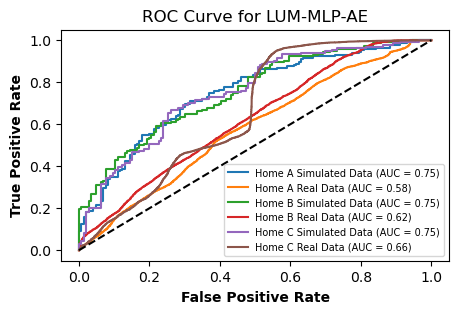

In [9]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import roc_curve, roc_auc_score
from tensorflow.keras.models import load_model
import matplotlib.pyplot as plt

def evaluate_and_plot_roc(data_path_train, data_path_test, model_path, threshold_path, label):
    # Load train and test data
    train_data = pd.read_csv(data_path_train)
    test_data = pd.read_csv(data_path_test)

    # Extract features (X) and labels (y) from both datasets
    X_train = train_data.drop(columns=['Label']).values
    y_train = train_data['Label'].values
    X_test = test_data.drop(columns=['Label']).values
    y_test = test_data['Label'].values

    # Data preprocessing (scaling)
    scaler = MinMaxScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # Load the trained autoencoder model
    autoencoder = load_model(model_path)

    # Calculate reconstruction error for test data
    test_predictions = autoencoder.predict(X_test_scaled)
    test_reconstruction_error = np.mean(np.square(X_test_scaled - test_predictions), axis=1)

    # Load the saved threshold
    threshold = np.load(threshold_path)

    # Classify anomalies based on the threshold
    anomalies = test_reconstruction_error > threshold

    # Calculate ROC curve and AUC
    fpr_curve, tpr_curve, _ = roc_curve(y_test, test_reconstruction_error)
    roc_auc = roc_auc_score(y_test, test_reconstruction_error)

    # Plot ROC curve
    plt.plot(fpr_curve, tpr_curve, label=f'{label} (AUC = {roc_auc:.2f})')

# Define a list of dataset configurations
datasets = [
    {
        'train_path': "C:/Users/olufe/projects/Journal/dataset/psa_journal_home_A_unsupervise_train.csv",
        'test_path': "C:/Users/olufe/projects/Journal/dataset/psa_journal_home_A_sim_test.csv",
        'model_path': "trained_autoencoder_model.h5",
        'threshold_path': "trained_threshold.npy",
        'label': "Home A Simulated Data"
    },
    {
        'train_path': "C:/Users/olufe/projects/Journal/dataset/psa_journal_home_A_unsupervise_train.csv",
        'test_path': "C:/Users/olufe/projects/Journal/dataset/psa_journal_home_A_real_test.csv",
        'model_path': "trained_autoencoder_model.h5",
        'threshold_path': "trained_threshold.npy",
        'label': "Home A Real Data"
    },
    # Add configurations for the other datasets here
    {
        'train_path': "C:/Users/olufe/projects/Journal/dataset/psa_journal_home_B_unsupervise_train.csv",
        'test_path': "C:/Users/olufe/projects/Journal/dataset/psa_journal_home_B_sim_test.csv",
        'model_path': "trained_autoencoder_model.h5",
        'threshold_path': "trained_threshold.npy",
        'label': "Home B Simulated Data"
    },
    {
        'train_path': "C:/Users/olufe/projects/Journal/dataset/psa_journal_home_B_unsupervise_train.csv",
        'test_path': "C:/Users/olufe/projects/Journal/dataset/psa_journal_home_B_real_test.csv",
        'model_path': "trained_autoencoder_model.h5",
        'threshold_path': "trained_threshold.npy",
        'label': "Home B Real Data"
    },
    {
        'train_path': "C:/Users/olufe/projects/Journal/dataset/psa_journal_home_C_unsupervise_train.csv",
        'test_path': "C:/Users/olufe/projects/Journal/dataset/psa_journal_home_C_sim_test.csv",
        'model_path': "trained_autoencoder_model.h5",
        'threshold_path': "trained_threshold.npy",
        'label': "Home C Simulated Data"
    },
    {
        'train_path': "C:/Users/olufe/projects/Journal/dataset/psa_journal_home_C_unsupervise_train.csv",
        'test_path': "C:/Users/olufe/projects/Journal/dataset/psa_journal_home_C_real_test.csv",
        'model_path': "trained_autoencoder_model.h5",
        'threshold_path': "trained_threshold.npy",
        'label': "Home C Real Data"
    }
]

# Initialize the scaler
scaler = MinMaxScaler()

# Create a figure for the ROC curve
plt.figure(figsize=(5, 3))

# Loop through each dataset and plot ROC curve
for dataset in datasets:
    evaluate_and_plot_roc(dataset['train_path'], dataset['test_path'], dataset['model_path'], dataset['threshold_path'], dataset['label'])

# Plot the diagonal line for reference
plt.plot([0, 1], [0, 1], 'k--')

# Customize the plot
plt.xlabel('False Positive Rate', fontsize=10, fontweight='bold')
plt.ylabel('True Positive Rate', fontsize=10, fontweight='bold')
plt.title('ROC Curve for LUM-MLP-AE')
plt.legend(loc='lower right', fontsize=7)
plt.savefig(r'C:\Users\olufe\projects\Journal\Diagrams\LUM_UP\LUM_MLP-AE.png', bbox_inches='tight')
# Show the plot or save it to a file
plt.show()


548/548 [==============================] - 16s 29ms/step


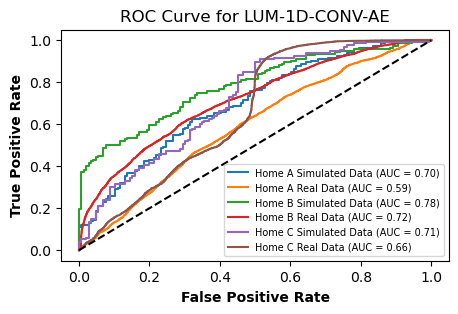

In [8]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import roc_curve, roc_auc_score
from tensorflow.keras.models import load_model
import matplotlib.pyplot as plt

# Define a function to evaluate and plot ROC curve for a given dataset
def evaluate_and_plot_roc(data_path_train, data_path_test, model_path, threshold_path, label):
    # Load train and test data
    train_data = pd.read_csv(data_path_train)
    test_data = pd.read_csv(data_path_test)

    # Extract features (X) and labels (y) from both datasets
    X_train = train_data.drop(columns=['Label']).values
    y_train = train_data['Label'].values
    X_test = test_data.drop(columns=['Label']).values
    y_test = test_data['Label'].values

    # Data preprocessing (scaling)
    scaler = MinMaxScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # Load the trained autoencoder model
    autoencoder = load_model(model_path)

    # Calculate reconstruction error for test data
    test_predictions = autoencoder.predict(X_test_scaled)
    test_predictions = np.squeeze(test_predictions)  # Remove the extra dimension
    test_reconstruction_error = np.mean(np.square(X_test_scaled - test_predictions), axis=1)

    # Load the saved threshold
    threshold = np.load(threshold_path)

    # Classify anomalies based on the threshold
    anomalies = test_reconstruction_error > threshold

    # Calculate ROC curve and AUC
    fpr_curve, tpr_curve, _ = roc_curve(y_test, test_reconstruction_error)
    roc_auc = roc_auc_score(y_test, test_reconstruction_error)

    # Plot ROC curve
    plt.plot(fpr_curve, tpr_curve, label=f'{label} (AUC = {roc_auc:.2f})')

# Define a list of dataset configurations
datasets = [
    {
        'train_path': "C:/Users/olufe/projects/Journal/dataset/psa_journal_home_A_unsupervise_train.csv",
        'test_path': "C:/Users/olufe/projects/Journal/dataset/psa_journal_home_A_sim_test.csv",
        'model_path': "trained_1D-autoencoder_model.h5",
        'threshold_path': "trained_1D-threshold.npy",
        'label': "Home A Simulated Data"
    },
    {
        'train_path': "C:/Users/olufe/projects/Journal/dataset/psa_journal_home_A_unsupervise_train.csv",
        'test_path': "C:/Users/olufe/projects/Journal/dataset/psa_journal_home_A_real_test.csv",
        'model_path': "trained_1D-autoencoder_model.h5",
        'threshold_path': "trained_1D-threshold.npy",
        'label': "Home A Real Data"
    },
    {
        'train_path': "C:/Users/olufe/projects/Journal/dataset/psa_journal_home_B_unsupervise_train.csv",
        'test_path': "C:/Users/olufe/projects/Journal/dataset/psa_journal_home_B_sim_test.csv",
        'model_path': "trained_1D-autoencoder_model.h5",
        'threshold_path': "trained_1D-threshold.npy",
        'label': "Home B Simulated Data"
    },
    {
        'train_path': "C:/Users/olufe/projects/Journal/dataset/psa_journal_home_B_unsupervise_train.csv",
        'test_path': "C:/Users/olufe/projects/Journal/dataset/psa_journal_home_B_real_test.csv",
        'model_path': "trained_1D-autoencoder_model.h5",
        'threshold_path': "trained_1D-threshold.npy",
        'label': "Home B Real Data"
    },
    {
        'train_path': "C:/Users/olufe/projects/Journal/dataset/psa_journal_home_C_unsupervise_train.csv",
        'test_path': "C:/Users/olufe/projects/Journal/dataset/psa_journal_home_C_sim_test.csv",
        'model_path': "trained_1D-autoencoder_model.h5",
        'threshold_path': "trained_1D-threshold.npy",
        'label': "Home C Simulated Data"
    },
    {
        'train_path': "C:/Users/olufe/projects/Journal/dataset/psa_journal_home_C_unsupervise_train.csv",
        'test_path': "C:/Users/olufe/projects/Journal/dataset/psa_journal_home_C_real_test.csv",
        'model_path': "trained_1D-autoencoder_model.h5",
        'threshold_path': "trained_1D-threshold.npy",
        'label': "Home C Real Data"
    }
]

# Initialize the scaler
scaler = MinMaxScaler()

# Create a figure for the ROC curve
plt.figure(figsize=(5, 3))

# Loop through each dataset and plot ROC curve
for dataset in datasets:
    evaluate_and_plot_roc(dataset['train_path'], dataset['test_path'], dataset['model_path'], dataset['threshold_path'], dataset['label'])

# Plot the diagonal line for reference
plt.plot([0, 1], [0, 1], 'k--')

# Customize the plot
plt.xlabel('False Positive Rate', fontsize=10, fontweight='bold')
plt.ylabel('True Positive Rate', fontsize=10, fontweight='bold')
plt.title('ROC Curve for LUM-1D-CONV-AE')
plt.legend(loc='lower right', fontsize=7)
plt.savefig(r'C:\Users\olufe\projects\Journal\Diagrams\LUM_UP\LUM_1D-CONV-AE.png', bbox_inches='tight')
# Show the plot or save it to a file
plt.show()


548/548 [==============================] - 1s 2ms/step


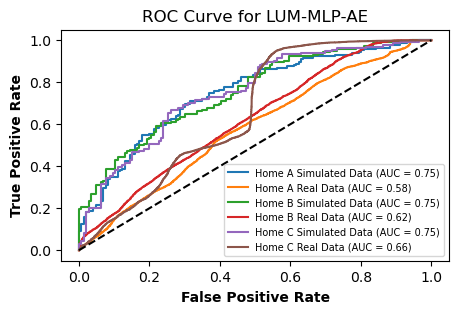

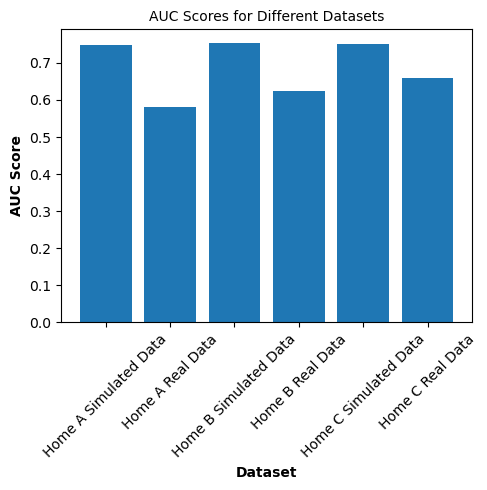

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import roc_curve, roc_auc_score
from tensorflow.keras.models import load_model

def evaluate_and_plot_roc(data_path_train, data_path_test, model_path, threshold_path, label, scaler, autoencoder):
    try:
        # Load train and test data
        train_data = pd.read_csv(data_path_train)
        test_data = pd.read_csv(data_path_test)
    except FileNotFoundError as e:
        print(f"Error loading data files: {e}")
        return None

    # Extract features (X) and labels (y) from both datasets
    X_train = train_data.drop(columns=['Label']).values
    y_train = train_data['Label'].values
    X_test = test_data.drop(columns=['Label']).values
    y_test = test_data['Label'].values

    # Data preprocessing (scaling)
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # Calculate reconstruction error for test data
    test_predictions = autoencoder.predict(X_test_scaled)
    test_reconstruction_error = np.mean(np.square(X_test_scaled - test_predictions), axis=1)

    # Load the saved threshold
    threshold = np.load(threshold_path)

    # Classify anomalies based on the threshold
    anomalies = test_reconstruction_error > threshold

    try:
        # Calculate ROC curve and AUC
        fpr_curve, tpr_curve, _ = roc_curve(y_test, test_reconstruction_error)
        roc_auc = roc_auc_score(y_test, test_reconstruction_error)

        # Plot ROC curve
        plt.plot(fpr_curve, tpr_curve, label=f'{label} (AUC = {roc_auc:.2f})')
    except Exception as e:
        print(f"Error in ROC calculation or plotting: {e}")
        return None

    return roc_auc

# Load the trained autoencoder model
try:
    autoencoder = load_model("trained_autoencoder_model.h5")
except Exception as e:
    print(f"Error loading model: {e}")
    exit()  # Exit if model cannot be loaded

# Define a list of dataset configurations
datasets = [
    {
        'train_path': "C:/Users/olufe/projects/Journal/dataset/psa_journal_home_A_unsupervise_train.csv",
        'test_path': "C:/Users/olufe/projects/Journal/dataset/psa_journal_home_A_sim_test.csv",
        'model_path': "trained_1D-autoencoder_model.h5",
        'threshold_path': "trained_1D-threshold.npy",
        'label': "Home A Simulated Data"
    },
    {
        'train_path': "C:/Users/olufe/projects/Journal/dataset/psa_journal_home_A_unsupervise_train.csv",
        'test_path': "C:/Users/olufe/projects/Journal/dataset/psa_journal_home_A_real_test.csv",
        'model_path': "trained_1D-autoencoder_model.h5",
        'threshold_path': "trained_1D-threshold.npy",
        'label': "Home A Real Data"
    },
    {
        'train_path': "C:/Users/olufe/projects/Journal/dataset/psa_journal_home_B_unsupervise_train.csv",
        'test_path': "C:/Users/olufe/projects/Journal/dataset/psa_journal_home_B_sim_test.csv",
        'model_path': "trained_1D-autoencoder_model.h5",
        'threshold_path': "trained_1D-threshold.npy",
        'label': "Home B Simulated Data"
    },
    {
        'train_path': "C:/Users/olufe/projects/Journal/dataset/psa_journal_home_B_unsupervise_train.csv",
        'test_path': "C:/Users/olufe/projects/Journal/dataset/psa_journal_home_B_real_test.csv",
        'model_path': "trained_1D-autoencoder_model.h5",
        'threshold_path': "trained_1D-threshold.npy",
        'label': "Home B Real Data"
    },
    {
        'train_path': "C:/Users/olufe/projects/Journal/dataset/psa_journal_home_C_unsupervise_train.csv",
        'test_path': "C:/Users/olufe/projects/Journal/dataset/psa_journal_home_C_sim_test.csv",
        'model_path': "trained_1D-autoencoder_model.h5",
        'threshold_path': "trained_1D-threshold.npy",
        'label': "Home C Simulated Data"
    },
    {
        'train_path': "C:/Users/olufe/projects/Journal/dataset/psa_journal_home_C_unsupervise_train.csv",
        'test_path': "C:/Users/olufe/projects/Journal/dataset/psa_journal_home_C_real_test.csv",
        'model_path': "trained_1D-autoencoder_model.h5",
        'threshold_path': "trained_1D-threshold.npy",
        'label': "Home C Real Data"
    }
]
    
# Initialize the scaler
scaler = MinMaxScaler()

# Create a figure for the ROC curve
plt.figure(figsize=(5, 3))

# Dictionary to hold AUC scores for bar chart
auc_scores = {}

# Loop through each dataset
for dataset in datasets:
    auc_score = evaluate_and_plot_roc(
        dataset['train_path'], 
        dataset['test_path'], 
        dataset['model_path'], 
        dataset['threshold_path'], 
        dataset['label'],
        scaler,
        autoencoder
    )
    if auc_score is not None:
        auc_scores[dataset['label']] = auc_score

# Plot the diagonal line for reference in ROC
plt.plot([0, 1], [0, 1], 'k--')

# Customize the ROC plot
plt.xlabel('False Positive Rate', fontsize=10, fontweight='bold')
plt.ylabel('True Positive Rate', fontsize=10, fontweight='bold')
plt.title('ROC Curve for LUM-MLP-AE')
plt.legend(loc='lower right', fontsize=7)
plt.savefig(r'C:\Users\olufe\projects\Journal\Diagrams\LUM_UP\LUM_MLP-AE.png', bbox_inches='tight')
plt.show()

# Check if there are AUC scores to plot
if auc_scores:
    # Create a bar chart for AUC scores
    plt.figure(figsize=(5, 5))
    plt.bar(range(len(auc_scores)), list(auc_scores.values()), align='center')
    plt.xticks(range(len(auc_scores)), list(auc_scores.keys()), rotation=45)
    plt.xlabel('Dataset', fontsize=10, fontweight='bold')
    plt.ylabel('AUC Score', fontsize=10, fontweight='bold')
    plt.title('AUC Scores for Different Datasets', fontsize=10)
    plt.tight_layout()
    plt.savefig(r'C:\Users\olufe\projects\Journal\Diagrams\LUM_UP\LUM_MLP-AE_bar.png', bbox_inches='tight')
    plt.show()
else:
    print("No AUC scores available for plotting.")

